##### 03 — EDA & Visualizations
**Goal:** Generate all charts for the GitHub README and PDF write-up.<br>
Power BI uses the CSVs from notebook 02. These charts are Python-native<br>
and go into the README as visual previews.<br>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import os

os.makedirs('../outputs', exist_ok = True)

#Global style - clean, minimal, professional
plt.rcParams.update({
    'font.family' : 'sans-serif',
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'axes.grid' : True,
    'grid.alpha' : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi' : 150,
    'axes.titlesize' : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize' : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10
})

print('✅ Style set')

✅ Style set


##### Chart 1 — Cohort Retention Heatmap
##### The single most important visual. Green = high retention, Red = churned.

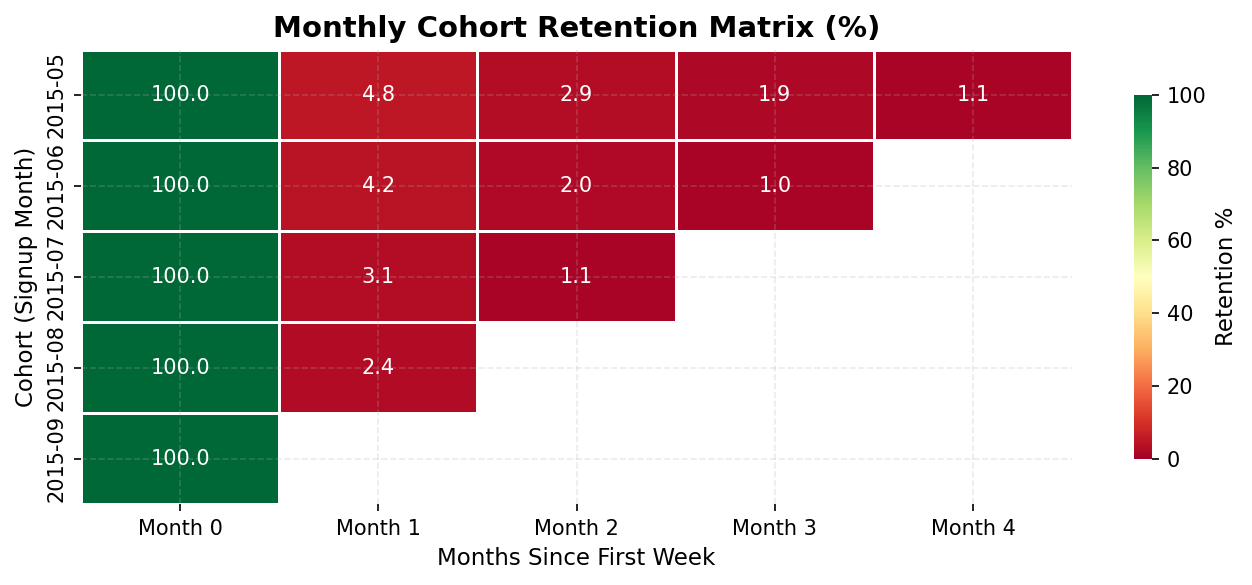

✅ cohort_heatmap.png saved


In [2]:
retention_matrix = pd.read_csv(r'..\outputs\retention_matrix.csv', index_col = 0)

fig, ax = plt.subplots(figsize = (9,4))
sns.heatmap(
    retention_matrix,
    annot = True,
    fmt = '.1f',
    cmap = 'RdYlGn',
    vmin = 0,
    vmax = 100,
    linewidths = 0.5,
    linecolor = 'white',
    ax = ax,
    cbar_kws = {'label' : 'Retention %', 'shrink' : 0.8}
)

ax.set_title('Monthly Cohort Retention Matrix (%)')
ax.set_xlabel('Months Since First Week')
ax.set_ylabel('Cohort (Signup Month)')
ax.set_xticklabels([c.replace('month_', 'Month ') for c in retention_matrix.columns])
plt.tight_layout()
plt.savefig('../outputs/cohort_heatmap.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print('✅ cohort_heatmap.png saved')

##### Chart 2 — Retention Curves (one line per cohort)
##### Shows how quickly each cohort drops off over time.retention_matrix

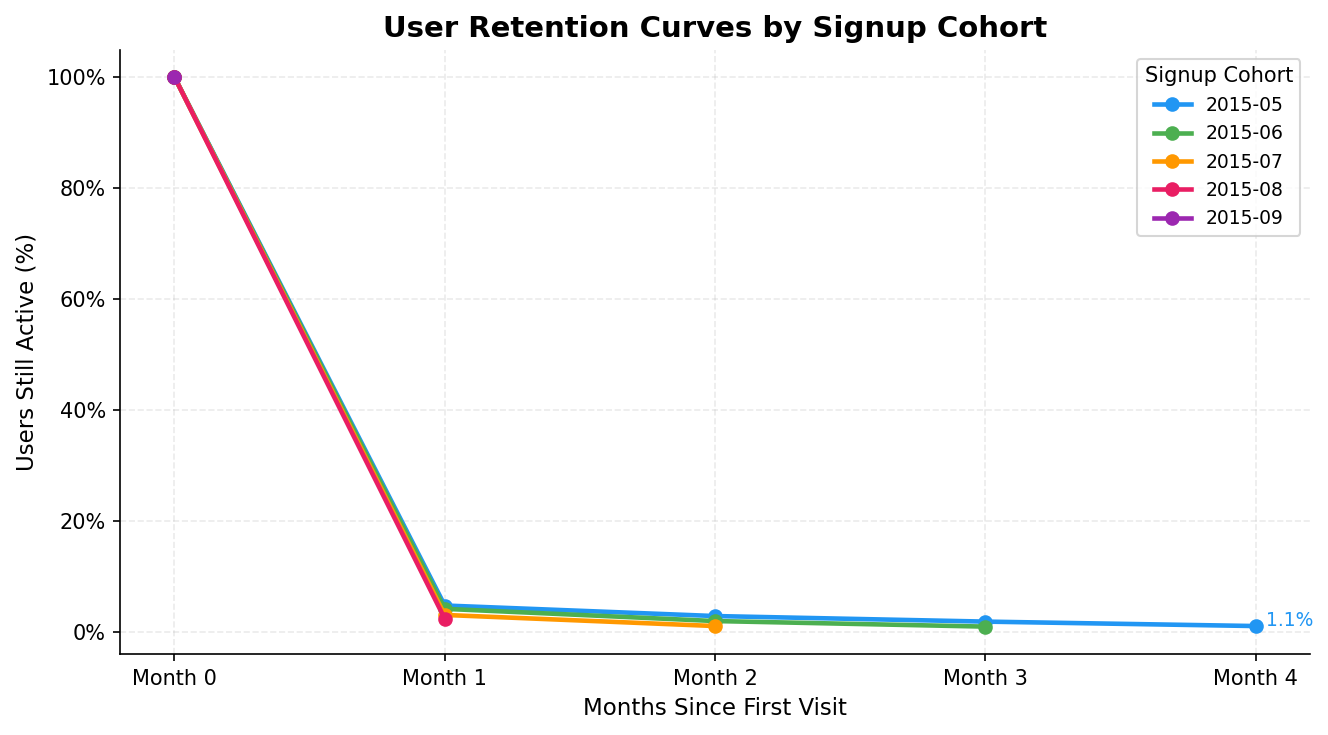

✅ retention_curves.png saved


In [3]:
fig, ax = plt.subplots(figsize = (9,5))
palette = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for i, (cohort, row) in enumerate(retention_matrix.iterrows()):
    x = [int(c.replace('month_', '')) for c in row.index]
    ax.plot(x, row.values, marker = 'o', linewidth = 2.2,
            label = cohort, color = palette[i % len(palette)])
    
    # Annotate end point
    ax.annotate(f'{row.values[-1]:.1f}%',
                xy = (x[-1], row.values[-1]),
                 xytext=(5, 0), textcoords='offset points',
                fontsize=9, color=palette[i % len(palette)])

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Months Since First Visit')
ax.set_ylabel('Users Still Active (%)')
ax.set_title('User Retention Curves by Signup Cohort')
ax.set_xticks(range(5))
ax.set_xticklabels([f'Month {i}' for i in range(5)])
ax.legend(title='Signup Cohort', fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ retention_curves.png saved")

##### Chart 3 — Purchase Funnel
##### Shows the drop-off at each stage of the user journey.

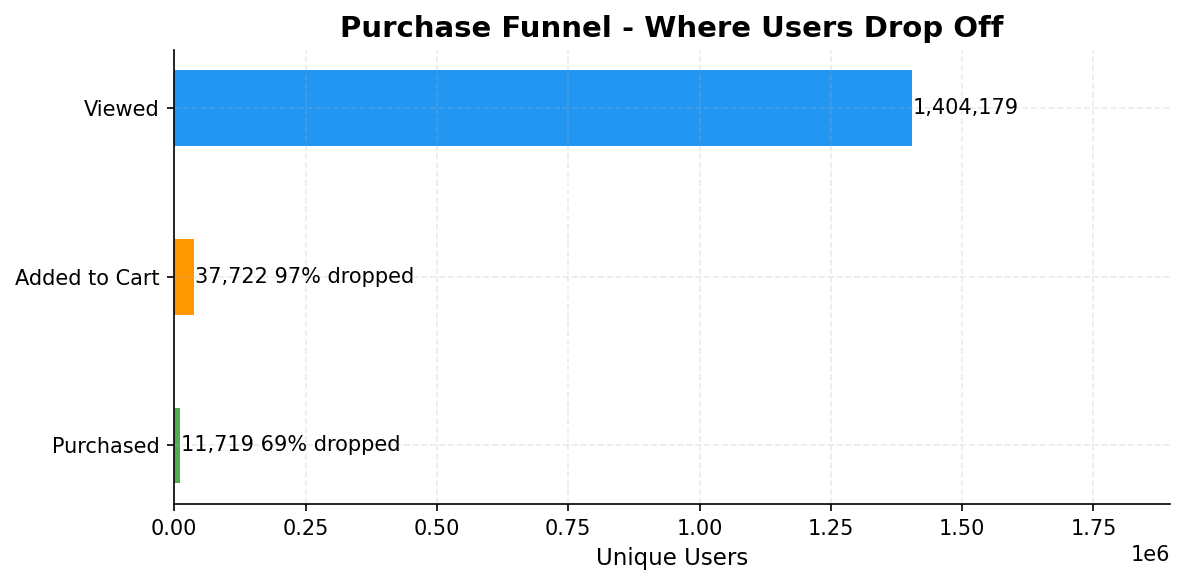

✅ funnel_chart.png saved


In [4]:
funnel = pd.read_csv('../outputs/funnel.csv')

fig, ax = plt.subplots(figsize = (8,4))

colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.barh(
    funnel['stage'][::-1],
    funnel['users'][::-1],
    color = colors[::-1], height = 0.45
)
for bar, row in zip(bars, funnel[::-1].itertuples()):
    label = f"{row.users:,}"
    if not pd.isna(row.drop_off_pct):
        label += f" {row.drop_off_pct:.0f}% dropped"
    ax.text(bar.get_width() + 2000,
            bar.get_y() + bar.get_height()/2,
            label, va = 'center', fontsize = 10)
ax.set_xlabel('Unique Users')
ax.set_title('Purchase Funnel - Where Users Drop Off')
ax.set_xlim(0, funnel['users'].max() * 1.35)
plt.tight_layout()
plt.savefig('../outputs/funnel_chart.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print('✅ funnel_chart.png saved')

##### Chart 4 — Week-1 Segment vs Future Purchase Rate
##### Higher bar = that behaviour in week 1 strongly predicts future purchase.funnel

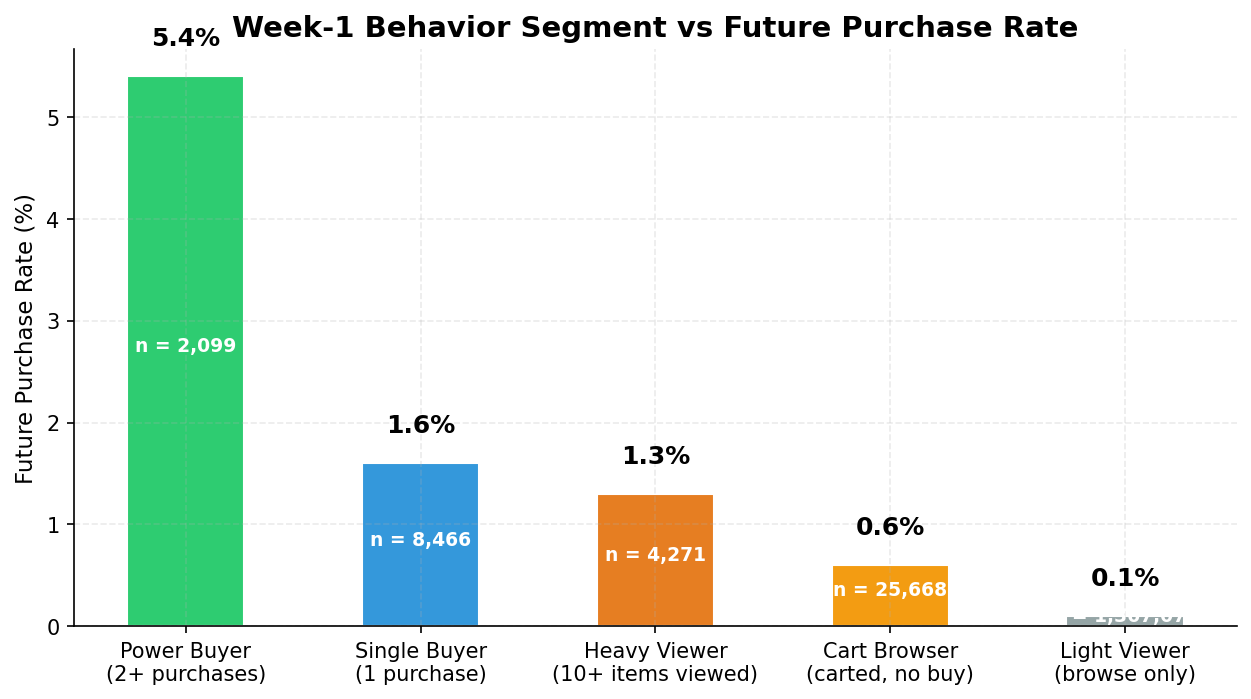

✅ segment_conversion.png saved


In [5]:
segments = pd.read_csv('../outputs/user_segments.csv')
seg_colors = {
    'power_buyer':  '#2ECC71',
    'single_buyer': '#3498DB',
    'cart_browser': '#F39C12',
    'heavy_viewer': '#E67E22',
    'light_viewer': '#95A5A6'
}
labels = {
    'power_buyer':  'Power Buyer\n(2+ purchases)',
    'single_buyer': 'Single Buyer\n(1 purchase)',
    'cart_browser': 'Cart Browser\n(carted, no buy)',
    'heavy_viewer': 'Heavy Viewer\n(10+ items viewed)',
    'light_viewer': 'Light Viewer\n(browse only)'
}

fig, ax = plt.subplots(figsize = (10,5))
x_labels = [labels.get(s,s) for s in segments['user_segment']]
bars = ax.bar(
    x_labels,
    segments['future_purchase_rate_pct'],
    color = [seg_colors.get(s, '#888') for s in segments['user_segment']],
    width = 0.5,
    edgecolor = 'white'
)

for bar, rate, users in zip(bars,
                                segments['future_purchase_rate_pct'],
                                segments['total_users']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{rate}%", ha = 'center', fontsize = 12, fontweight = 'bold')
    
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f"n = {users:,}", ha = 'center', fontsize = 9,
            color = 'white', fontweight = 'bold')
    
ax.set_ylabel('Future Purchase Rate (%)')
ax.set_title('Week-1 Behavior Segment vs Future Purchase Rate')
plt.tight_layout
plt.savefig('../outputs/segment_conversion.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print('✅ segment_conversion.png saved')

##### Chart 5 — 7-Day Rolling Transaction Trend
##### Spots growth trends and seasonal spikes without daily noise.

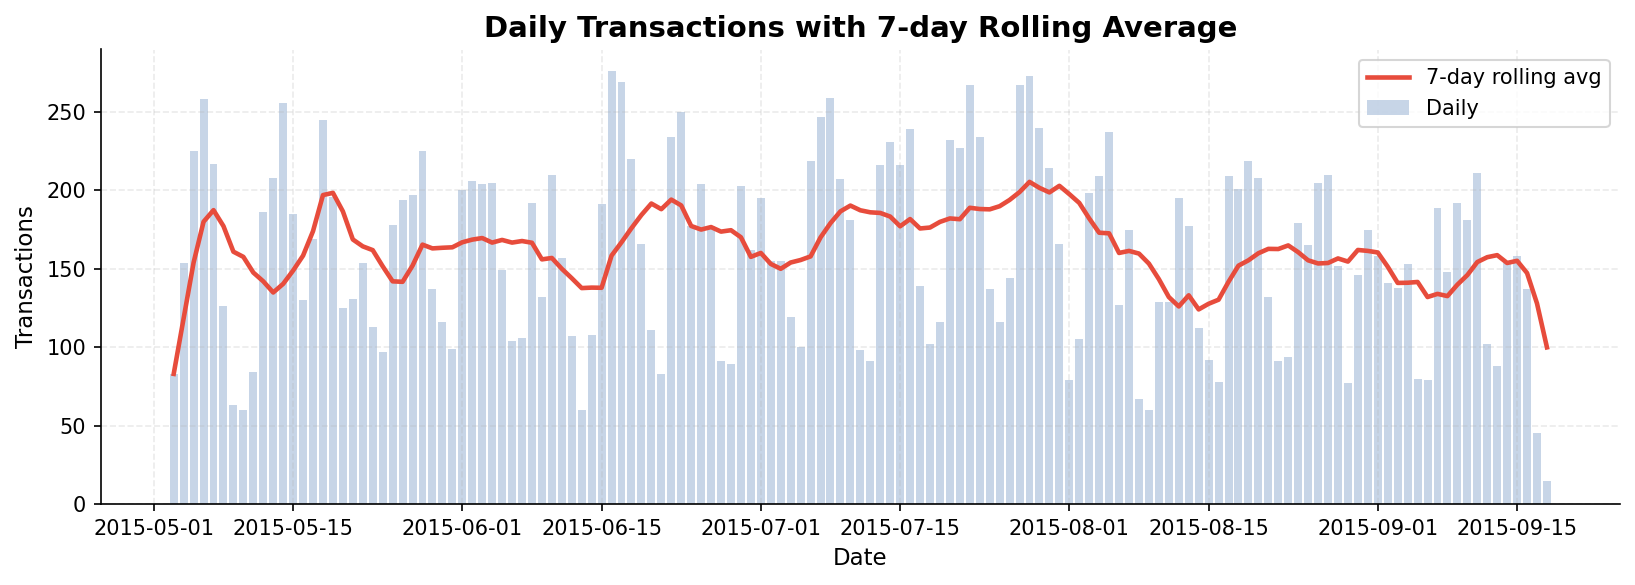

✅rolling_transactions.png saved


In [10]:
rolling = pd.read_csv('../outputs/rolling_transactions.csv', parse_dates=['txn_date'])


fig, ax = plt.subplots(figsize = (11,4))
ax.bar(rolling['txn_date'], rolling['daily_transactions'],
       color = '#B0C4DE', alpha = 0.7, label = 'Daily', width = 0.8)
ax.plot(rolling['txn_date'], rolling['rolling_7d_avg'],
        color = '#E74C3C', linewidth = 2.2, label = '7-day rolling avg')
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
ax.set_title('Daily Transactions with 7-day Rolling Average')
ax.legend(fontsize = 10)
plt.tight_layout()
plt.savefig('../outputs/rolling_transactions.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print('✅rolling_transactions.png saved')



##### Chart 6 — Churn Segment Donut
##### Proportion of users in each churn category.

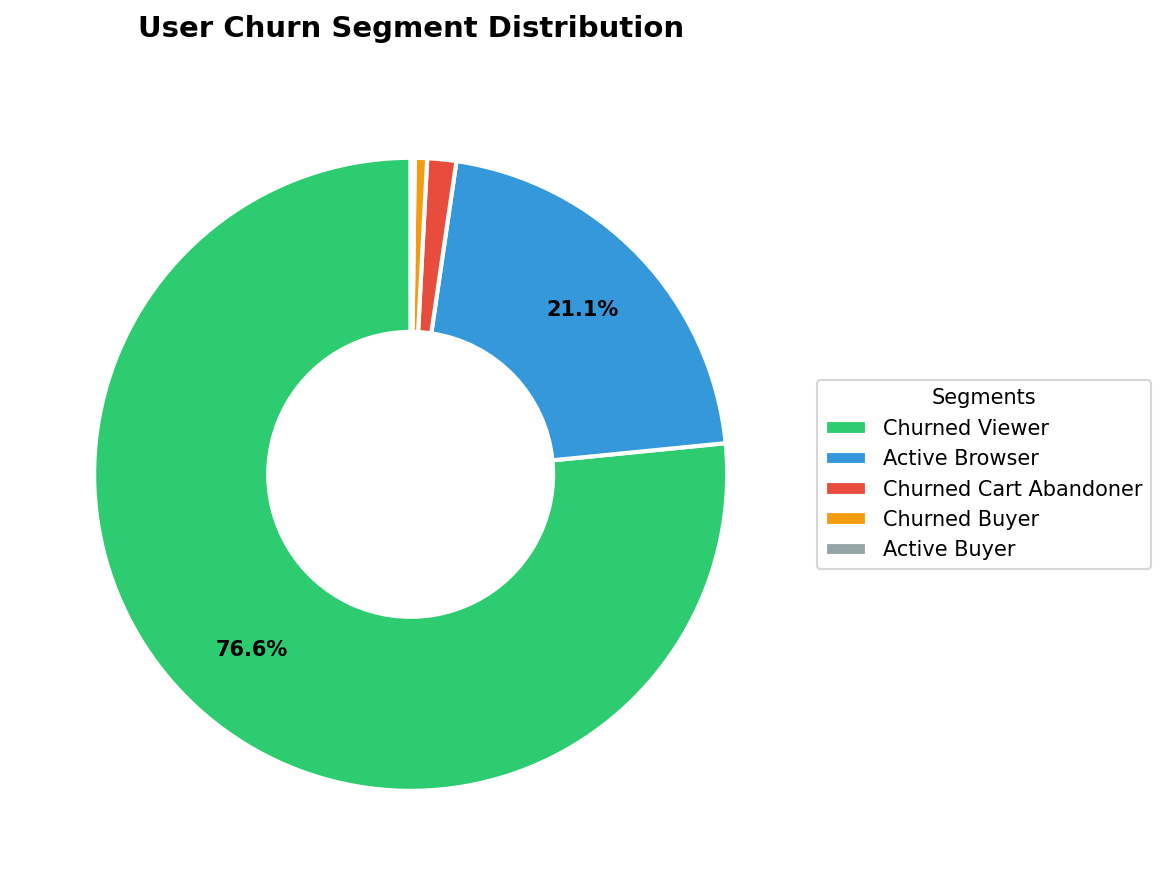

✅ churn_donut.png saved

✅ All 6 charts saved to outputs/


In [33]:
churn = pd.read_csv('../outputs/churn_segments.csv')
colors_c = ['#2ECC71','#3498DB','#E74C3C','#F39C12','#95A5A6']
readable = {
    'active_buyer':            'Active Buyer',
    'active_browser':          'Active Browser',
    'churned_buyer':           'Churned Buyer',
    'churned_cart_abandoner':  'Churned Cart Abandoner',
    'churned_viewer':          'Churned Viewer'
}
labels_c = [readable.get(l,l) for l in churn['churn_label']]

fig, ax = plt.subplots(figsize = (8,6))
wedges, texts, autotexts = ax.pie(
    churn['user_count'],
    labels = None,
    colors = colors_c[:len(churn)],
    autopct = lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle = 90,
    wedgeprops = dict(width = 0.55, edgecolor = 'white', linewidth = 2),
    pctdistance = 0.75,
    labeldistance = 1
)

for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax.set_title('User Churn Segment Distribution', pad = 20)
ax.legend(wedges, labels_c, title="Segments",
          loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig('../outputs/churn_donut.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print('✅ churn_donut.png saved')
print('\n✅ All 6 charts saved to outputs/')